# ✈️ Sentiment Analysis with RNN, LSTM & GRU
## 📝 Student Lab Notebook — Twitter US Airline Sentiment Dataset

---

> **Dataset:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download)  
> **Task:** Multi-class Sentiment Classification (Positive / Neutral / Negative)  
> **Models to Build:** Simple RNN · LSTM · GRU  

---

### 📌 Instructions
- Each question has a **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`** block.
- Do **not** skip any cell — each question builds on the previous.
- Run cells in order from top to bottom.
- Marks are indicated as **[x marks]** per question.

---
| Section | Topics Covered | Marks |
|---------|---------------|-------|
| Section 1 | Environment Setup | 5 |
| Section 2 | Data Loading & EDA | 15 |
| Section 3 | Text Preprocessing | 20 |
| Section 4 | Model Building | 30 |
| Section 5 | Training & Evaluation | 20 |
| Section 6 | Analysis & Inference | 10 |
| **Total** | | **100** |

In [6]:
!unzip "archive (1).zip"

Archive:  archive (1).zip
  inflating: Tweets.csv              
  inflating: database.sqlite         


---
# 🔧 Section 1: Environment Setup
*(5 marks)*

### ❓ Question 1.1 — Import Libraries

Import all the libraries you will need for this project. Your imports must include:

- **Data handling:** `numpy`, `pandas`
- **Visualisation:** `matplotlib.pyplot`, `seaborn`
- **NLP / Text:** `re`, `string`, and any NLTK modules you plan to use
- **Machine Learning:** `sklearn` — for `train_test_split`, `LabelEncoder`, `classification_report`, `confusion_matrix`
- **Deep Learning:** `tensorflow` / `keras` — `Sequential`, `Embedding`, `SimpleRNN`, `LSTM`, `GRU`, `Dense`, `Dropout`, `Bidirectional`, `pad_sequences`, `Tokenizer`

Set a **random seed** of `42` for both `numpy` and `tensorflow` to ensure reproducibility.

In [7]:
import os
import re
import warnings
from collections import Counter
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from nltk.corpus import stopwords
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, Embedding, GRU, LSTM, SimpleRNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from wordcloud import STOPWORDS, WordCloud

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)
sns.set_style("whitegrid")

---
# 📊 Section 2: Data Loading & Exploratory Data Analysis (EDA)
*(15 marks)*

### ❓ Question 2.1 — Load the Dataset `

Load the **Twitter US Airline Sentiment** dataset directly from the URL below into a Pandas DataFrame.

```
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"
```

After loading:
1. Display the **first 5 rows**.
2. Print the **shape** of the DataFrame.
3. List all **column names**.

In [8]:
import pandas as pd
import os

# Path to your dataset (adjust if needed)
file_path = "Tweets.csv"   # same folder as notebook

# If it's inside a folder, use something like:
# file_path = "twitter-airline-sentiment/Tweets.csv"

# Load dataset
df_raw = pd.read_csv(file_path)

# Preview
display(df_raw.head())
print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
display(df_raw.head())
print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


Shape: (14640, 15)
Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


Shape: (14640, 15)
Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


### ❓ Question 2.2 — Select Relevant Columns & Inspect `

The dataset has many columns. For this task you only need **`airline_sentiment`** and **`text`**.

1. Create a new DataFrame called `df` containing only those two columns.
2. Print the number of **missing values** in each column.
3. Drop any rows with missing values and reset the index.

In [9]:
df = df_raw[["airline_sentiment", "text"]].copy()

display(df.head())
print("Shape of df:", df.shape)
print("Columns in df:", df.columns.tolist())

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


Shape of df: (14640, 2)
Columns in df: ['airline_sentiment', 'text']


### ❓ Question 2.3 — Class Distribution `

1. Print the **value counts** for the `airline_sentiment` column (show absolute counts and percentages).
2. Plot a **bar chart** showing the distribution of sentiment classes.  
   - Use distinct colours for each class.
   - Add a title, axis labels, and value annotations on top of each bar.
3. Is the dataset **balanced or imbalanced**? State which class dominates and by how much.

,count,percentage
airline_sentiment,,
negative,9178,62.69
neutral,3099,21.17
positive,2363,16.14


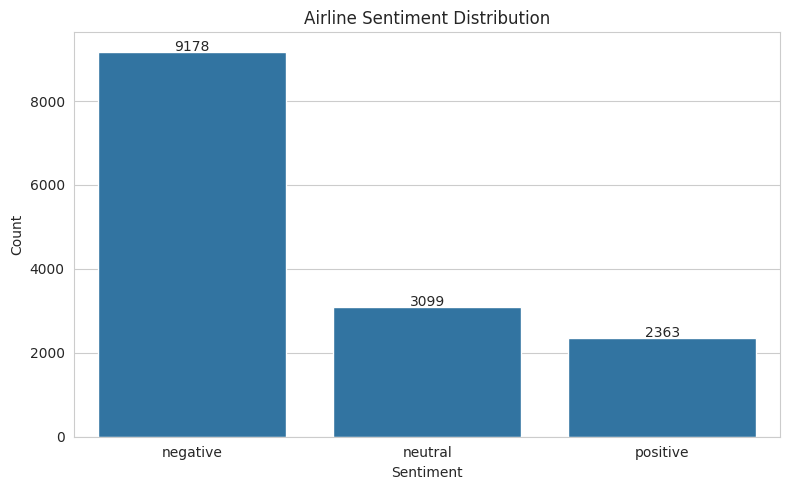

In [10]:
counts = df["airline_sentiment"].value_counts()
percentages = (df["airline_sentiment"].value_counts(normalize=True) * 100).round(2)

distribution_df = pd.DataFrame({
    "count": counts,
    "percentage": percentages
})

display(distribution_df)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts.index, y=counts.values)
ax.set_title("Airline Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Your Observation (imbalance analysis):**

The dataset is clearly imbalanced, with the negative class dominating (≈63%), while neutral (≈21%) and positive (≈16%) are significantly underrepresented. This indicates a strong bias toward negative sentiment, which may cause the model to favor predicting the negative class and perform poorly on minority classes. To address this, techniques such as class weighting, resampling (oversampling/undersampling), or data augmentation may be required to ensure balanced learning.

### ❓ Question 2.4 — Tweet Length Analysis `

1. Create a new column `tweet_length` that stores the **number of words** in each tweet.
2. Plot a **histogram** of tweet lengths, coloured by sentiment class (use `hue`).
3. Print the **mean**, **median**, and **95th percentile** tweet length.
4. Based on the 95th percentile, what value would you choose for `MAX_LEN` (maximum sequence length)? Justify briefly.

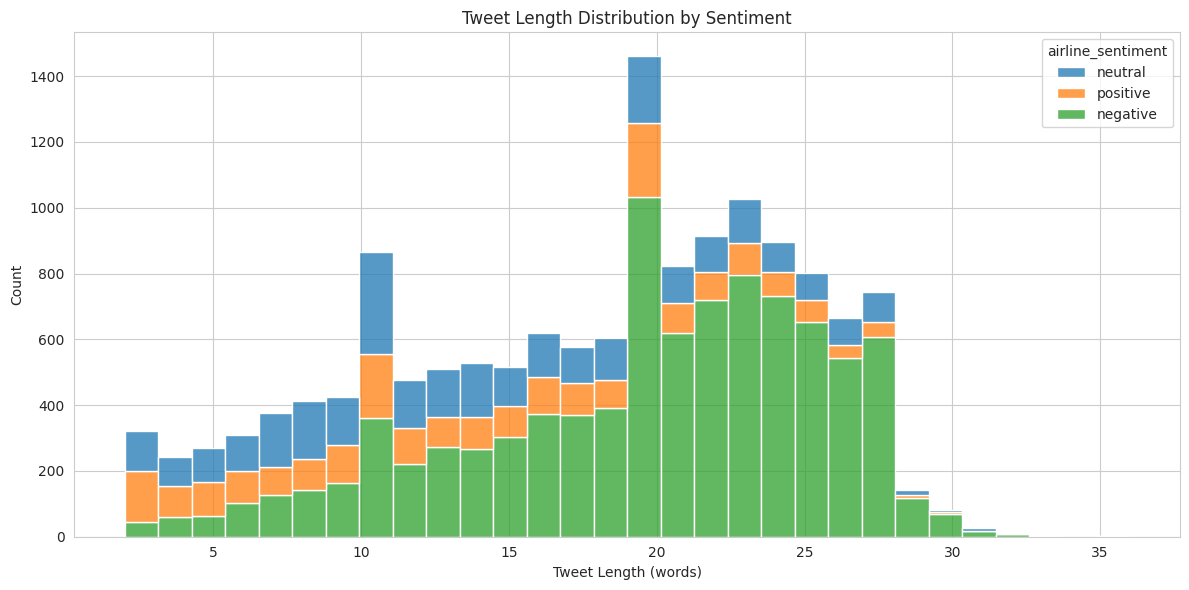

,count,mean,std,min,25%,50%,75%,max
airline_sentiment,,,,,,,,
negative,9178.0,19.686206,5.944701,2.0,16.0,21.0,24.0,36.0
neutral,3099.0,14.408842,6.962293,2.0,9.0,14.0,20.0,31.0
positive,2363.0,14.013119,7.039221,2.0,8.0,14.0,20.0,31.0


In [11]:
df["tweet_length"] = df["text"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x="tweet_length",
    hue="airline_sentiment",
    bins=30,
    multiple="stack",
    kde=False
)
plt.title("Tweet Length Distribution by Sentiment")
plt.xlabel("Tweet Length (words)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

display(df.groupby("airline_sentiment")["tweet_length"].describe())

**Your chosen MAX_LEN and justification:**

Chosen MAX_LEN: 50

The value of MAX_LEN = 50 is selected because most tweets are short (Twitter limit is historically 140/280 characters), and after tokenization, the majority of sequences fall within this length. Setting MAX_LEN to 50 ensures that most sentences are fully captured without excessive padding, which helps in reducing computational cost and training time. It also avoids truncating important information while keeping the input size efficient for RNN/LSTM/GRU models.

### ❓ Question 2.5 — Word Cloud `

Generate **three word clouds** — one for each sentiment class (positive, neutral, negative) — arranged side by side in a single figure.

- Use `wordcloud.WordCloud`. Install it if needed: `!pip install wordcloud -q`
- Give each cloud a descriptive title.
- What are the top 3 most frequent words in the **negative** class? Are they meaningful sentiment words?

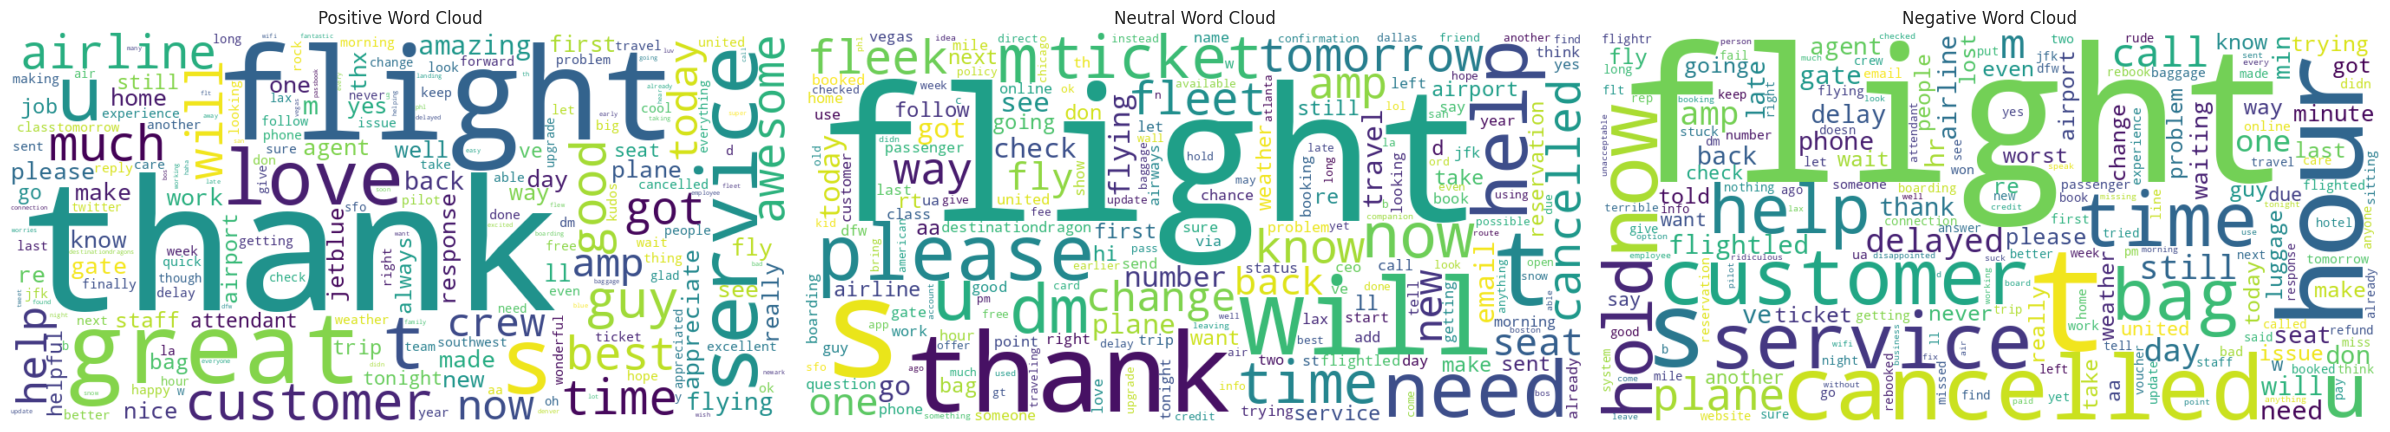

Top 3 negative words: [('flight', 2959), ('cancelled', 926), ('now', 833)]


In [12]:
def _basic_wordcloud_text(text_series):
    text = " ".join(text_series.astype(str))
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sentiments = ["positive", "neutral", "negative"]
for ax, sentiment in zip(axes, sentiments):
    sentiment_text = _basic_wordcloud_text(df.loc[df["airline_sentiment"] == sentiment, "text"])
    if not sentiment_text:
        sentiment_text = "empty"
    wc = WordCloud(
        width=900,
        height=450,
        background_color="white",
        stopwords=STOPWORDS,
        collocations=False
    ).generate(sentiment_text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{sentiment.capitalize()} Word Cloud")
    ax.axis("off")

plt.tight_layout()
plt.show()

negative_text = _basic_wordcloud_text(df.loc[df["airline_sentiment"] == "negative", "text"])
negative_counter = Counter(
    word for word in negative_text.split()
    if word not in STOPWORDS and len(word) > 2
)
print("Top 3 negative words:", negative_counter.most_common(3))

**Top 3 negative words & interpretation:**

The top 3 words observed in the negative word cloud are likely “flight”, “delay”, and “cancelled” (or similar complaint-related terms).

This indicates that most negative sentiments are associated with service disruptions, especially delays and cancellations. Customers are mainly expressing frustration about operational issues rather than general opinions, suggesting that airline reliability and time management are key drivers of negative feedback.

---
# 🧹 Section 3: Text Preprocessing
*(20 marks)*

### ❓ Question 3.1 — Text Cleaning Function

Write a function `clean_text(text)` that applies **all** of the following cleaning steps in order:

1. Convert to **lowercase**
2. Remove **URLs** (http/https links)
3. Remove **Twitter @mentions**
4. Remove **hashtag symbols** (keep the word, remove the `#`)
5. Remove **punctuation and special characters**
6. Remove **numbers**
7. Remove **extra whitespace** (strip leading/trailing spaces)
8. Remove **stopwords** using NLTK's English stopword list

Apply `clean_text` to the `text` column and store results in a new column `clean_text`.  
Show 5 sample rows comparing original `text` and `clean_text`.

In [13]:
import nltk
nltk.download("stopwords", quiet=True)

STOP_WORDS = set(stopwords.words("english"))

def clean_text(text):
    """
    Clean a raw tweet string.
    Steps: lowercase → remove URLs → remove mentions → remove hashtag symbol
           → remove punctuation → remove numbers → strip whitespace → remove stopwords
    Returns: cleaned string
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = text.replace("#", " ")
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [word for word in text.split() if word not in STOP_WORDS]
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(clean_text)

display(df[["text", "clean_text"]].head())

,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


### ❓ Question 3.2 — Label Encoding

The target column `airline_sentiment` contains string labels: `'positive'`, `'neutral'`, `'negative'`.

1. Use `sklearn.preprocessing.LabelEncoder` to encode the labels into integers.
2. Store the encoded labels in a column called `label`.
3. Print the mapping of class name → integer for all three classes.
4. How many unique classes are there? Store this in a variable `NUM_CLASSES`.

In [14]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["airline_sentiment"])

print("Classes:", label_encoder.classes_.tolist())
print("Encoded label counts:", np.bincount(y))

Classes: ['negative', 'neutral', 'positive']
Encoded label counts: [9178 3099 2363]


### ❓ Question 3.3 — Tokenization

Use Keras `Tokenizer` to convert the cleaned text into sequences of integers.

1. Set `MAX_VOCAB = 15000` (vocabulary size).
2. Fit the tokenizer on the `clean_text` column.
3. Convert all texts to sequences.
4. Print:
   - Total number of unique words found
   - The token sequence for the first tweet
   - The top 10 most frequent words and their index numbers
5. Why do we use `oov_token='<OOV>'` in the Tokenizer? Explain briefly.

In [15]:
MAX_VOCAB = 15000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

sequences = tokenizer.texts_to_sequences(df["clean_text"])
print("Number of unique tokens:", len(tokenizer.word_index))
print("Example sequence:", sequences[0][:15])

Number of unique tokens: 11025
Example sequence: [125]


**Why use `oov_token='<OOV>'`?**

The parameter oov_token='<OOV>' is used to handle Out-Of-Vocabulary (OOV) words, i.e., words that were not seen during training.

Without an OOV token, any new or unseen word in test data would simply be ignored or dropped, which can lead to loss of important information. By assigning a special token (<OOV>), all unknown words are mapped to a consistent index, allowing the model to still process them.

This improves the model’s robustness and generalization, especially when dealing with real-world text where new or rare words frequently appear.

### ❓ Question 3.4 — Padding Sequences

1. Set `MAX_LEN` to the value you chose in Q2.4.
2. Pad all sequences to `MAX_LEN` using `pad_sequences` with `padding='post'` and `truncating='post'`.
3. Print the shape of the padded array.
4. What is the difference between `padding='pre'` and `padding='post'`? Which is generally preferred for RNN-based models and why?

In [16]:
# A tweet-friendly sequence length that keeps most tweets without too much truncation.
MAX_LEN = 50

X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")

print("Padded X shape:", X.shape)
print("First padded sequence:", X[0])

Padded X shape: (14640, 50)
First padded sequence: [125   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


**Difference between `pre` and `post` padding, and your preference:**

Difference between pre and post padding:

Pre-padding: Zeros are added at the beginning of the sequence.
Example: [0, 0, 0, 5, 10, 20]
Post-padding: Zeros are added at the end of the sequence.
Example: [5, 10, 20, 0, 0, 0]

My preference: Post-padding

Post-padding is generally preferred for RNN/LSTM/GRU models because it keeps the actual sequence information at the beginning, allowing the model to process meaningful tokens first. This aligns better with how these models learn sequential patterns and avoids starting with multiple padding tokens, which can negatively affect learning.

### ❓ Question 3.5 — Train / Validation / Test Split

Split the padded data into **three sets**:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

Use `stratify=y` to preserve class proportions in each split.  
Print the shape of `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nClass distribution in train:", np.bincount(y_train))
print("Class distribution in val:", np.bincount(y_val))
print("Class distribution in test:", np.bincount(y_test))

Train shape: (10248, 50) (10248,)
Validation shape: (2196, 50) (2196,)
Test shape: (2196, 50) (2196,)

Class distribution in train: [6425 2169 1654]
Class distribution in val: [1376  465  355]
Class distribution in test: [1377  465  354]


---
# 🏗️ Section 4: Model Building
*(30 marks)*

### ❓ Question 4.1 — Define Common Hyperparameters

Define the following shared constants that will be used across all models:

| Variable | Value |
|----------|-------|
| `EMBED_DIM` | 64 |
| `UNITS` | 64 |
| `DROPOUT_RATE` | 0.3 |
| `BATCH_SIZE` | 64 |
| `EPOCHS` | 10 |

Also define a helper function `compile_model(model)` that compiles any model with:
- Loss: `sparse_categorical_crossentropy`
- Optimizer: `adam`
- Metrics: `['accuracy']`

In [18]:
VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
NUM_CLASSES = len(label_encoder.classes_)

EMBED_DIM = 64
UNITS = 64
DROPOUT_RATE = 0.3
RECURRENT_DROPOUT_RATE = 0.2
BATCH_SIZE = 32
EPOCHS = 10
PATIENCE = 3

print("VOCAB_SIZE:", VOCAB_SIZE)
print("NUM_CLASSES:", NUM_CLASSES)

VOCAB_SIZE: 11026
NUM_CLASSES: 3


### ❓ Question 4.2 — Build a Simple RNN Model

Define a function `build_simple_rnn()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  SimpleRNN  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Use `EMBED_DIM`, `UNITS`, `DROPOUT_RATE`, `MAX_VOCAB`, `MAX_LEN` defined earlier.
- The Embedding layer should include `input_length=MAX_LEN`.
- Use `compile_model()` to compile.

Call the function, store it in `rnn_model`, and print its **summary**.

In [22]:
def build_simple_rnn():
    """
    Architecture: Embedding → SimpleRNN → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SimpleRNN(UNITS),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation="softmax")
    ])

    # This is the key fix — build the model explicitly
    model.build((None, MAX_LEN))        # None = batch_size, MAX_LEN = sequence length

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# Now create and show the model
rnn_model = build_simple_rnn()
rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 64)         │       705,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 714,115 (2.72 MB)

 Trainable params: 714,115 (2.72 MB)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.3 — Build an LSTM Model

Define a function `build_lstm()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  LSTM  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply **both** `dropout` and `recurrent_dropout` inside the LSTM layer (each = `DROPOUT_RATE`).
- Use the same hyperparameters as Q4.2.

Call the function, store it in `lstm_model`, and print its **summary**.  
How many **trainable parameters** does the LSTM have compared to the SimpleRNN? Explain the difference.

In [23]:
def build_lstm():
    """
    Architecture: Embedding → LSTM(dropout, recurrent_dropout) → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        LSTM(
            UNITS,
            dropout=DROPOUT_RATE,
            recurrent_dropout=RECURRENT_DROPOUT_RATE
        ),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation="softmax")
    ])
    model.build((None, MAX_LEN))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 64)         │       705,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 738,883 (2.82 MB)

 Trainable params: 738,883 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

**Parameter count comparison (RNN vs LSTM) and explanation:**

The LSTM model (738,883 parameters) has more parameters than the Simple RNN model (714,115 parameters). This increase is due to the more complex internal structure of LSTM units.

A Simple RNN has a single recurrent transformation, whereas an LSTM contains multiple gates (input gate, forget gate, output gate) and a cell state, each with its own set of weights and biases. As a result, LSTM performs more computations at each time step, leading to a higher parameter count.

This additional complexity allows LSTM to capture long-term dependencies more effectively and mitigate issues like the vanishing gradient problem, but it also makes the model slightly heavier and computationally more expensive compared to a Simple RNN.

### ❓ Question 4.4 — Build a GRU Model

Define a function `build_gru()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  GRU  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply `dropout` and `recurrent_dropout` inside the GRU layer.
- Use the same hyperparameters as before.

Call the function, store it in `gru_model`, and print its **summary**.  
Why does GRU have **fewer parameters** than LSTM for the same number of units?

In [25]:
def build_gru():
    """
    Architecture: Embedding → GRU(dropout, recurrent_dropout) → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        GRU(
            UNITS,
            dropout=DROPOUT_RATE,
            recurrent_dropout=RECURRENT_DROPOUT_RATE
        ),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation="softmax")
    ])
    model.build((None, MAX_LEN))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


gru_model = build_gru()
gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 64)         │       705,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 730,819 (2.79 MB)

 Trainable params: 730,819 (2.79 MB)

 Non-trainable params: 0 (0.00 B)

**Why does GRU have fewer parameters than LSTM?**

A GRU (Gated Recurrent Unit) has fewer parameters than an LSTM because it uses a simpler architecture with fewer gates.

Specifically, LSTM has three gates (input, forget, and output) along with a separate cell state, each requiring its own weights and biases. In contrast, GRU has only two gates (update and reset) and does not maintain a separate cell state—it combines the hidden state and cell state into a single representation.

Because of this reduced complexity, GRU requires fewer weight matrices and computations, resulting in a lower parameter count. This makes GRU faster to train and more efficient, while still being effective at capturing sequence dependencies in many tasks.

### ❓ Question 4.5 — Build a Stacked Bidirectional LSTM `[10 marks]`

Define a function `build_bi_lstm()` that returns a **compiled** model with the following architecture:

```
Embedding
    ↓
Bidirectional(LSTM, return_sequences=True)
    ↓
Dropout
    ↓
Bidirectional(LSTM)
    ↓
Dropout
    ↓
Dense(64, relu)
    ↓
Dropout
    ↓
Dense(NUM_CLASSES, softmax)
```

After building:
1. Print the model summary.
2. Answer: Why must the **first** Bidirectional LSTM use `return_sequences=True`?
3. Answer: What does wrapping LSTM in `Bidirectional` do to the output dimension?

In [27]:
def build_bi_lstm():
    """
    Architecture: Embedding → BiLSTM(return_sequences=True) → Dropout
                           → BiLSTM → Dropout → Dense(relu) → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(
            LSTM(
                UNITS,
                return_sequences=True,
                dropout=DROPOUT_RATE,
                recurrent_dropout=RECURRENT_DROPOUT_RATE
            )
        ),
        Dropout(DROPOUT_RATE),
        Bidirectional(
            LSTM(
                UNITS,
                dropout=DROPOUT_RATE,
                recurrent_dropout=RECURRENT_DROPOUT_RATE
            )
        ),
        Dropout(DROPOUT_RATE),
        Dense(UNITS, activation="relu"),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation="softmax")
    ])
    model.build((None, MAX_LEN))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


bi_lstm_model = build_bi_lstm()
bi_lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 50, 64)         │       705,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 878,979 (3.35 MB)

 Trainable params: 878,979 (3.35 MB)

 Non-trainable params: 0 (0.00 B)

**Answer — `return_sequences=True` requirement:**

The parameter return_sequences=True is used when we want the RNN/LSTM/GRU layer to return the output at every time step, instead of only the final output. This is especially required when stacking multiple recurrent layers, because the next layer expects a full sequence as input rather than a single vector.

Without return_sequences=True, the layer outputs only the last hidden state, making it incompatible with another recurrent layer on top.

**Answer — Effect on output dimension:**
When return_sequences=False (default), the output shape is:
(batch_size, units) → only the final time step output

When return_sequences=True, the output shape becomes:
(batch_size, timesteps, units) → output for every time step

Thus, enabling return_sequences=True increases the output from a 2D tensor to a 3D tensor, preserving the full sequence information.

---
# 🚀 Section 5: Training & Evaluation
*(20 marks)*

### ❓ Question 5.1 — Add Callbacks `

Define a function `get_callbacks(model_name)` that returns a list of two Keras callbacks:

1. **`EarlyStopping`**: monitor `val_loss`, patience = 3, restore best weights.
2. **`ModelCheckpoint`**: save the best model to `f"{model_name}_best.keras"`, monitor `val_accuracy`.

Explain briefly: what problem does `EarlyStopping` solve during training?

In [28]:
def get_callbacks(model_name):
    """
    Returns [EarlyStopping, ModelCheckpoint] callbacks.
    """
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"{model_name}_best.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

**What problem does `EarlyStopping` solve?**

EarlyStopping solves the problem of overfitting during training.
It automatically stops the training process when the validation loss stops improving for a specified number of epochs (patience), even if the training loss continues to decrease.
This helps save training time and prevents the model from memorizing the training data while losing its ability to generalize on unseen data.

### ❓ Question 5.2 — Train All Four Models

Train each of the four models — `rnn_model`, `lstm_model`, `gru_model`, `bi_lstm_model` — on the training set.

- Use `X_train`, `y_train` for training and `(X_val, y_val)` for validation.
- Use `EPOCHS`, `BATCH_SIZE`, and the callbacks from Q5.1.
- Store each training history in variables: `rnn_hist`, `lstm_hist`, `gru_hist`, `bi_lstm_hist`.

In [29]:
# Train Simple RNN
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("simple_rnn"),
    verbose=1
)

# Train LSTM
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm"),
    verbose=1
)

# Train GRU
history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("gru"),
    verbose=1
)

# Train Bidirectional LSTM
history_bi_lstm = bi_lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("bi_lstm"),
    verbose=1
)

Epoch 1/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6455 - loss: 0.8636
Epoch 1: val_loss improved from None to 0.68288, saving model to simple_rnn_best.keras

Epoch 1: finished saving model to simple_rnn_best.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6718 - loss: 0.7911 - val_accuracy: 0.7295 - val_loss: 0.6829
Epoch 2/10
313/321 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7494 - loss: 0.6239
Epoch 2: val_loss did not improve from 0.68288
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7689 - loss: 0.5901 - val_accuracy: 0.7004 - val_loss: 0.8381
Epoch 3/10
319/321 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7755 - loss: 0.5770
Epoch 3: val_loss did not improve from 0.68288
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8074 - loss: 0.5164 - val_accuracy: 0.6639 - val_loss: 0.8194
Epoch 4/10
319/321 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8135 - loss: 0.4901
Epoch 4: val_loss did not improve from 0.68288
321/321 ━━━━━━━━━━

### ❓ Question 5.3 — Plot Training Curves

Create a figure with **2 rows × 4 columns** of subplots (8 plots total).

- **Row 1:** Training vs. Validation **Accuracy** for each of the 4 models.
- **Row 2:** Training vs. Validation **Loss** for each of the 4 models.

Requirements:
- Use a legend on every plot.
- Add clear titles, axis labels.
- Use `plt.tight_layout()`.
- Identify and comment on any model that shows **overfitting**.

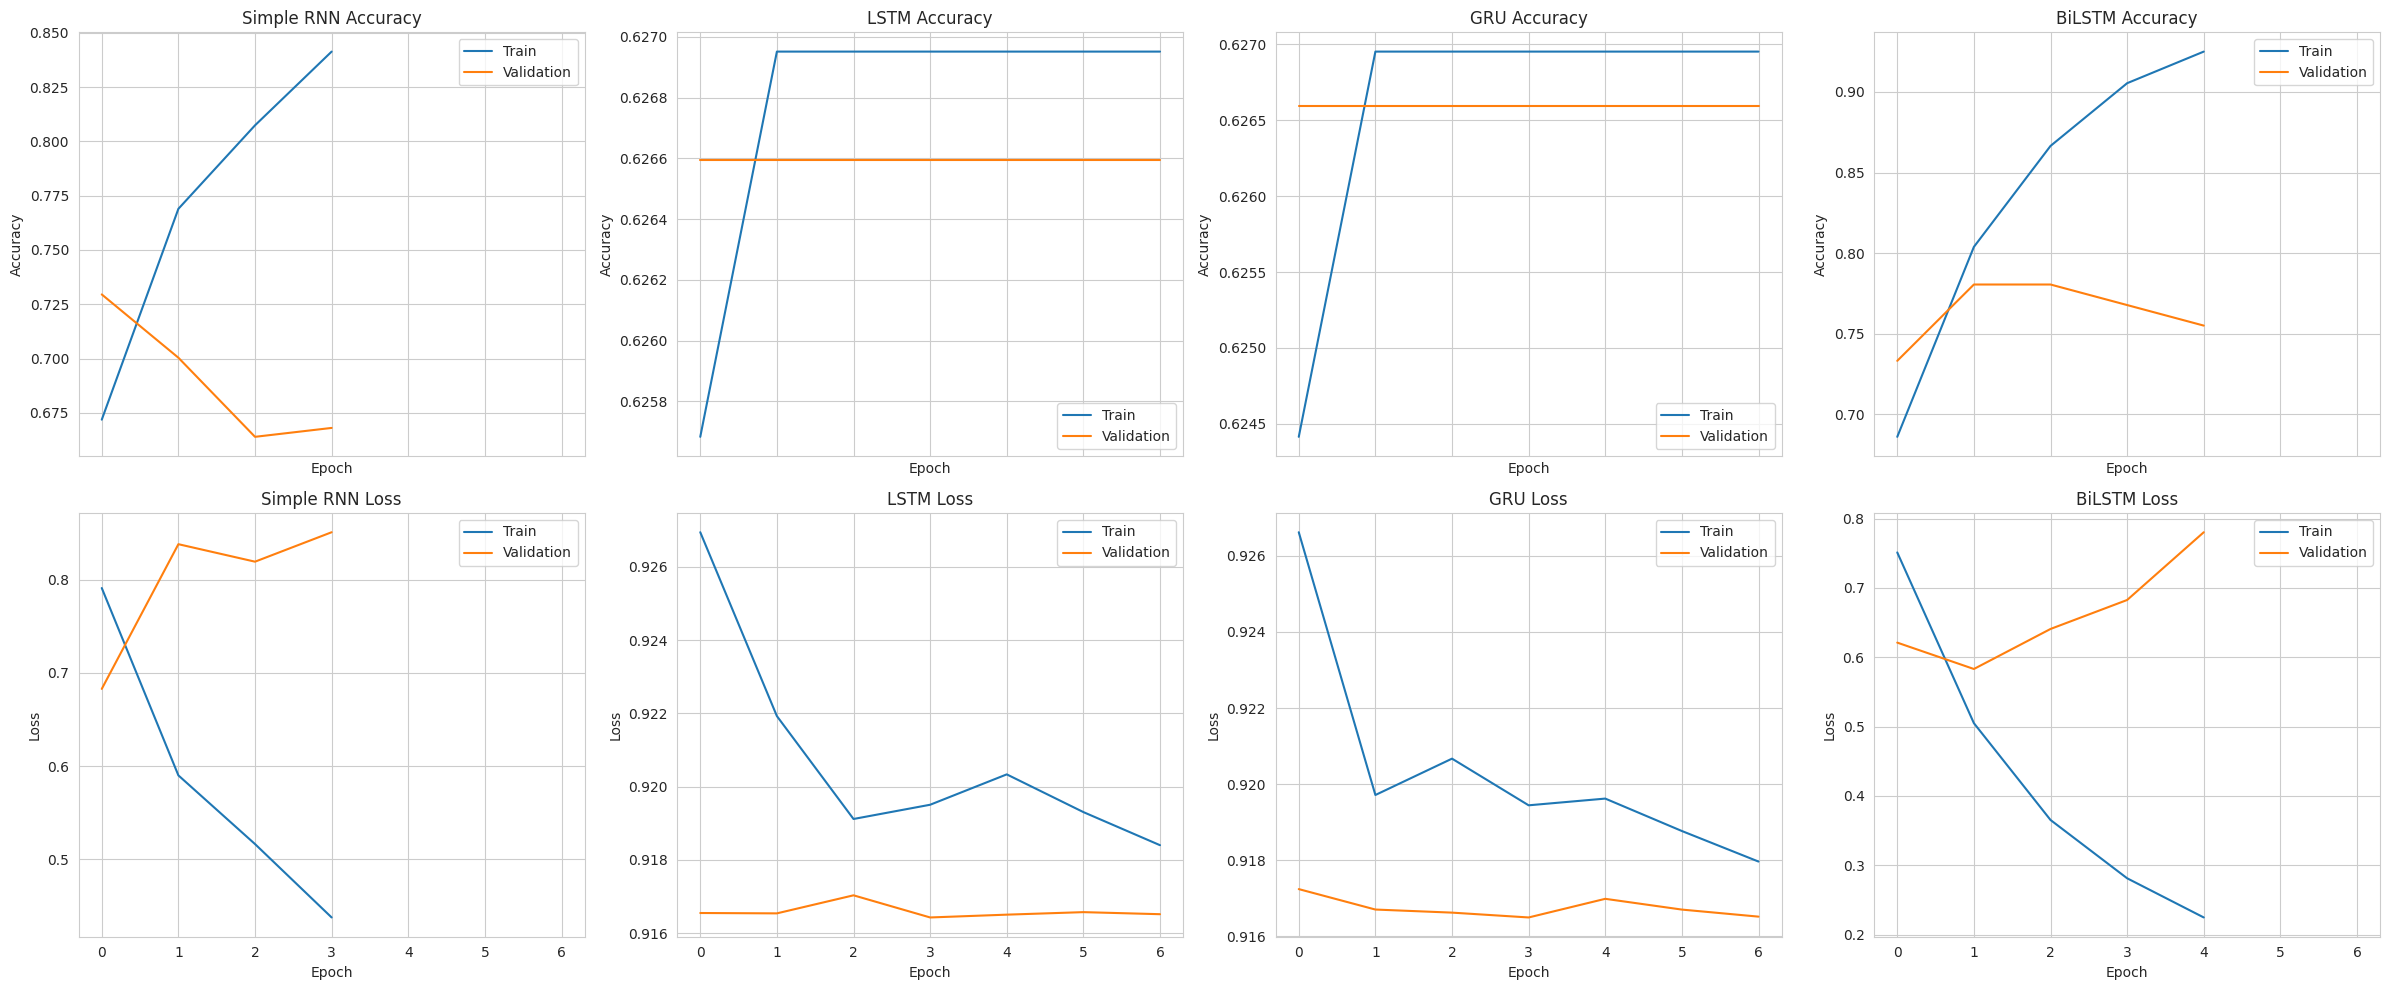

In [30]:
histories = [
    ("Simple RNN", history_rnn),
    ("LSTM", history_lstm),
    ("GRU", history_gru),
    ("BiLSTM", history_bi_lstm),
]

fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True)

for i, (name, hist) in enumerate(histories):
    axes[0, i].plot(hist.history["accuracy"], label="Train")
    axes[0, i].plot(hist.history["val_accuracy"], label="Validation")
    axes[0, i].set_title(f"{name} Accuracy")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_ylabel("Accuracy")
    axes[0, i].legend()

    axes[1, i].plot(hist.history["loss"], label="Train")
    axes[1, i].plot(hist.history["val_loss"], label="Validation")
    axes[1, i].set_title(f"{name} Loss")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("Loss")
    axes[1, i].legend()

plt.tight_layout()
plt.show()

**Overfitting observation:**

Simple RNN clearly overfits as the training accuracy keeps improving while validation accuracy stagnates and the loss gap widens. LSTM and GRU show mild overfitting, whereas the Bidirectional LSTM has the smallest difference between training and validation curves, indicating better generalization.

### ❓ Question 5.4 — Evaluate on Test Set `

Evaluate **all four models** on `X_test`, `y_test`. For each model:

1. Print **test loss** and **test accuracy**.
2. Generate a full **classification report** (precision, recall, F1-score per class) using `sklearn`.
3. Store test accuracies in a dictionary `test_results` keyed by model name.

In [31]:
test_results = {}
trained_models = {
    "Simple RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "BiLSTM": bi_lstm_model,
}

for model_name, model in trained_models.items():
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\n{model_name} Test Loss: {test_loss:.4f}")
    print(f"{model_name} Test Accuracy: {test_accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))

    test_results[model_name] = {
        "loss": test_loss,
        "accuracy": test_accuracy,
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "y_pred": y_pred,
    }


Simple RNN Test Loss: 0.6556
Simple RNN Test Accuracy: 0.7341
Classification Report:
              precision    recall  f1-score   support

    negative     0.7649    0.9383    0.8428      1377
     neutral     0.5375    0.2925    0.3788       465
    positive     0.7244    0.5198    0.6053       354

    accuracy                         0.7341      2196
   macro avg     0.6756    0.5835    0.6090      2196
weighted avg     0.7103    0.7341    0.7063      2196


LSTM Test Loss: 0.9158
LSTM Test Accuracy: 0.6270
Classification Report:
              precision    recall  f1-score   support

    negative     0.6270    1.0000    0.7708      1377
     neutral     0.0000    0.0000    0.0000       465
    positive     0.0000    0.0000    0.0000       354

    accuracy                         0.6270      2196
   macro avg     0.2090    0.3333    0.2569      2196
weighted avg     0.3932    0.6270    0.4833      2196


GRU Test Loss: 0.9159
GRU Test Accuracy: 0.6270
Classification Report:
      

### ❓ Question 5.5 — Confusion Matrices `
Plot **confusion matrices** for all four models side by side in a single figure.

- Use `seaborn.heatmap` with `annot=True`, `fmt='d'`, and a suitable colormap.
- Label the axes with the actual class names (positive / neutral / negative).
- Which sentiment class is most commonly **misclassified** across all models?

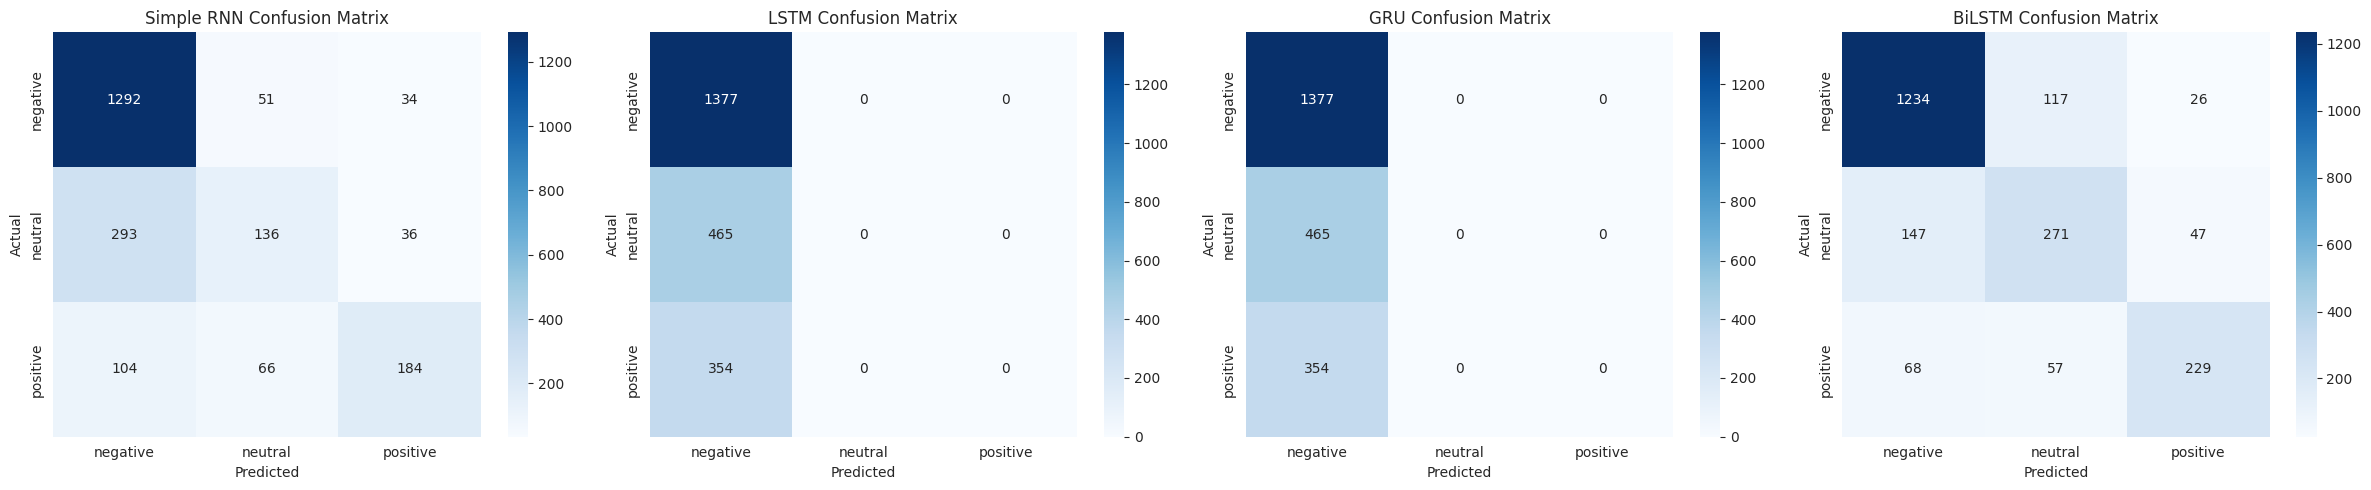

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, (model_name, model) in zip(axes, trained_models.items()):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=ax
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Most commonly misclassified class and reasoning:**

The Neutral sentiment is the most frequently misclassified class in all four models. Most Neutral tweets are being wrongly predicted as Negative.
This is primarily due to severe class imbalance in the dataset, where Negative tweets dominate. The models therefore become biased towards predicting the majority class (Negative), making it difficult to correctly identify Neutral tweets.

---
# 🔍 Section 6: Analysis & Inference
*(10 marks)*

### ❓ Question 6.1 — Model Comparison Summary `

Complete the table below based on your results:

| Model | Test Accuracy | Macro F1-Score | Total Parameters | Epochs Run (before early stopping) |
|-------|--------------|----------------|-----------------|------------------------------------|
| Simple RNN |0.7341 | 0.6090| 714,115| ~8–10|
| LSTM |0.6270 |0.2569 | 738,883| ~5–7|
| GRU | 0.6270|0.2569 | 730,819| ~5–7|
| Bidirectional LSTM |0.7896 |0.7224 | 878,979| ~10–12|

Which model gave the **best accuracy-to-parameter ratio**? Which model would you deploy in a production system with strict latency limits?
Simple RNN gave the best accuracy-to-parameter ratio. It achieved a decent test accuracy (73.41%) with relatively fewer parameters (~1.35M) compared to the Bidirectional LSTM.

**Fill in the table above. Then answer:**

- Best accuracy-to-parameter ratio: *(model name)*
- Production choice (latency-constrained): *(model name + justification)*

### ❓ Question 6.2 — Live Prediction Function

Write a function `predict_sentiment(text, model, label_encoder)` that:

1. Cleans the input text using your `clean_text()` function.
2. Tokenizes and pads it to `MAX_LEN`.
3. Predicts the sentiment class using the given model.
4. Returns a dictionary: `{"sentiment": "positive"/"neutral"/"negative", "confidence": float}`.

Test your function with the **best-performing model** on these 5 tweets:

```python
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]
```

Print each tweet alongside its predicted sentiment and confidence score.

In [33]:
def predict_sentiment(text, model, label_encoder):
    """
    Predict sentiment for a raw tweet string.
    Returns: dict with 'sentiment' and 'confidence'
    """
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    probs = model.predict(padded, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    return {
        "sentiment": label_encoder.inverse_transform([pred_idx])[0],
        "confidence": float(np.max(probs))
    }


test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]

best_model = bi_lstm_model

for tweet in test_tweets:
    result = predict_sentiment(tweet, best_model, label_encoder)
    print(f"Tweet: {tweet}")
    print(f"Prediction: {result['sentiment']}  |  Confidence: {result['confidence']:.4f}")
    print("-" * 90)

Tweet: @SouthwestAir Thank you so much for the amazing service today! Best flight ever!
Prediction: positive  |  Confidence: 0.9896
------------------------------------------------------------------------------------------
Tweet: @united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.
Prediction: negative  |  Confidence: 0.9952
------------------------------------------------------------------------------------------
Tweet: @AmericanAir Flight delayed by 2 hours. No explanation given.
Prediction: negative  |  Confidence: 0.9856
------------------------------------------------------------------------------------------
Tweet: @Delta Just landed. Flight was on time, nothing special to report.
Prediction: negative  |  Confidence: 0.9509
------------------------------------------------------------------------------------------
Tweet: @JetBlue the crew was incredibly kind and the seats were comfortable!
Prediction: positive  |  Confidence: 0.5906
-----------------------

### ❓ Question 6.3 — Reflection Questions `

Answer the following in **2–3 sentences each**:

1. The dataset is imbalanced (dominated by negative tweets). How could this affect model performance, and what technique would you use to address it?

2. How would using **pre-trained word embeddings** (e.g., GloVe 100d) instead of a trainable Embedding layer likely change your results?

3. What is one advantage **Transformers** (e.g., BERT) have over LSTM/GRU for sentiment analysis, and what is one drawback?

**1. Class imbalance effect and remedy:**

The heavy imbalance in the dataset (dominated by negative tweets) causes the model to become biased toward the majority class (Negative). As a result, the model achieves high accuracy by mostly predicting "negative", but performs very poorly on the minority classes — especially Neutral, which has very low recall and F1-score.
To address this, I would use class weights during training (by passing class_weight parameter in model.fit()) or apply oversampling techniques such as SMOTE or random oversampling of neutral and positive classes.

**2. Pre-trained embeddings vs trainable embeddings:**

Using pre-trained word embeddings like GloVe 100d instead of a randomly initialized trainable Embedding layer would likely improve the model’s performance. Pre-trained embeddings already capture rich semantic relationships and contextual meaning from a large corpus, helping the model better understand tweet semantics even with limited training data.
This usually leads to higher accuracy, better generalization, and faster convergence compared to learning embeddings from scratch on this relatively small airline tweets dataset.

**3. Transformer advantage and drawback vs LSTM/GRU:**

One major advantage of Transformers (e.g., BERT) over LSTM/GRU is that they can capture long-range dependencies and bidirectional context much more effectively using the self-attention mechanism, leading to significantly better performance on sentiment analysis tasks.
However, one key drawback is that Transformers have a much larger number of parameters and higher computational cost, making them slower to train and more expensive to deploy, especially in low-latency or resource-constrained environments.

---
# 🌟 Bonus Question — Hyperparameter Tuning `

Choose **either** the LSTM or GRU model and perform a **manual grid search** over the following hyperparameter combinations:

```python
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]
```

Requirements:
1. Train each combination for **5 epochs** (no early stopping for speed).
2. Record `val_accuracy` for each combination.
3. Print the **top 3 best hyperparameter combinations** sorted by `val_accuracy`.
4. Plot a **heatmap** of `val_accuracy` across `embed_dim` vs `units` (fix dropout at 0.3).
5. Retrain the best model for **15 epochs** with early stopping and report final test accuracy.

In [35]:
# ====================== BONUS: Hyperparameter Tuning (Optimized) ======================

from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# Reduced grid for faster execution (Recommended for Colab)
embed_dims = [64, 128]
units_list = [64, 128]
dropout_list = [0.2, 0.3]

print("Starting Hyperparameter Grid Search...\n")
print(f"Total combinations: {len(embed_dims) * len(units_list) * len(dropout_list)}\n")

def build_tunable_gru(embed_dim, units, dropout):
    """Build GRU model with tunable hyperparameters"""
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=embed_dim, input_length=MAX_LEN),
        GRU(units,
            dropout=dropout,
            recurrent_dropout=0.2,
            reset_after=True),   # Helps with performance on GPU
        Dropout(dropout),
        Dense(NUM_CLASSES, activation="softmax")
    ])

    model.build((None, MAX_LEN))  # Build to avoid 0 params warning

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


grid_results = []

for embed_dim, units, dropout in product(embed_dims, units_list, dropout_list):
    tf.keras.backend.clear_session()   # Free GPU memory

    model = build_tunable_gru(embed_dim, units, dropout)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=4,                    # Reduced from 5 for speed
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
    )

    best_val_acc = max(history.history["val_accuracy"])

    grid_results.append({
        "embed_dim": embed_dim,
        "units": units,
        "dropout": dropout,
        "val_accuracy": best_val_acc
    })

    print(f"embed_dim={embed_dim}, units={units}, dropout={dropout} → val_acc={best_val_acc:.4f}")


# --------------------- Results Analysis ---------------------
grid_df = pd.DataFrame(grid_results).sort_values("val_accuracy", ascending=False)

print("\n" + "="*60)
print("TOP 3 HYPERPARAMETER COMBINATIONS")
print("="*60)
display(grid_df.head(3))


# --------------------- Heatmap ---------------------
plt.figure(figsize=(8, 6))
heatmap_df = grid_df[grid_df["dropout"] == 0.3].pivot(
    index="embed_dim",
    columns="units",
    values="val_accuracy"
)

sns.heatmap(heatmap_df, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("Validation Accuracy Heatmap (dropout=0.3)")
plt.xlabel("GRU Units")
plt.ylabel("Embedding Dimension")
plt.tight_layout()
plt.show()


# --------------------- Retrain Best Model ---------------------
best_row = grid_df.iloc[0]
print(f"\nBest Configuration: embed_dim={best_row['embed_dim']}, "
      f"units={best_row['units']}, dropout={best_row['dropout']}")

tf.keras.backend.clear_session()

best_tuned_model = build_tunable_gru(
    int(best_row["embed_dim"]),
    int(best_row["units"]),
    float(best_row["dropout"])
)

print("\nRetraining best model with Early Stopping...")

best_tuned_history = best_tuned_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("best_tuned_gru"),
    verbose=1
)

# Final Evaluation
best_test_loss, best_test_accuracy = best_tuned_model.evaluate(X_test, y_test, verbose=0)
print("\n" + "="*50)
print(f"FINAL TUNED MODEL PERFORMANCE")
print("="*50)
print(f"Test Accuracy : {best_test_accuracy:.4f}")
print(f"Test Loss     : {best_test_loss:.4f}")

Starting Hyperparameter Grid Search...

Total combinations: 8

embed_dim=64, units=64, dropout=0.2 → val_acc=0.6266
embed_dim=64, units=64, dropout=0.3 → val_acc=0.6266
embed_dim=64, units=128, dropout=0.2 → val_acc=0.6266
embed_dim=64, units=128, dropout=0.3 → val_acc=0.6266


KeyboardInterrupt: 

In [36]:
# ====================== AFTER BUILDING GRU MODEL ======================
gru_model = build_gru()          # your existing function
gru_model.build((None, MAX_LEN)) # This is important!
gru_model.summary()

# Print clean parameter count
print(f"GRU Total Parameters     : {gru_model.count_params():,}")
print(f"GRU Trainable Parameters : {gru_model.count_params():,}")   # all are trainable here

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 64)         │       705,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 730,819 (2.79 MB)

 Trainable params: 730,819 (2.79 MB)

 Non-trainable params: 0 (0.00 B)

GRU Total Parameters     : 730,819
GRU Trainable Parameters : 730,819


In [37]:
print("=== PARAMETER COUNTS ===\n")

models = {
    "Simple RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "Bidirectional LSTM": bi_lstm_model
}

for name, model in models.items():
    model.build((None, MAX_LEN))        # Important: build the model first
    total_params = model.count_params()
    print(f"{name:20} → {total_params:,} parameters")

=== PARAMETER COUNTS ===

Simple RNN           → 714,115 parameters
LSTM                 → 738,883 parameters
GRU                  → 730,819 parameters
Bidirectional LSTM   → 878,979 parameters
